# 🏡 House Price Prediction using Machine Learning

## Project Overview

House price prediction is a supervised machine learning regression problem where the objective is to estimate the selling price of a house based on its characteristics. Accurate price prediction assists buyers, sellers, and real estate companies in making informed decisions by providing data-driven property valuations.

This project develops a machine learning model to predict house prices using property attributes such as location, number of bedrooms, bathrooms, living area, lot size, and other relevant features. The project follows a complete data science workflow, including data preprocessing, exploratory data analysis (EDA), feature engineering, model training, evaluation, and performance comparison.

---

## Problem Statement

Real estate prices are influenced by multiple factors including property size, location, amenities, and market conditions. Estimating property values manually is time-consuming and often subjective. The objective of this project is to build a predictive regression model capable of accurately estimating house prices from historical housing data.

---

## Business Objective

The primary objectives of this project are:

- Understand the factors affecting house prices.
- Perform exploratory data analysis to identify trends and relationships.
- Clean and preprocess the dataset for machine learning.
- Train regression models to predict house prices.
- Evaluate model performance using appropriate regression metrics.
- Identify the most influential features affecting house prices.

---

## Machine Learning Workflow

1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Cleaning
5. Feature Engineering
6. Data Preprocessing
7. Model Building
8. Model Evaluation
9. Conclusion
10. Future Improvements

# Dataset Description

## Dataset Overview

The dataset used in this project contains residential property information and corresponding house prices. Each record represents a single house along with its structural and location-related characteristics. These features are used to train a machine learning regression model that predicts the selling price of a house.

The dataset includes both numerical and categorical variables describing various aspects of a property.

---

## Target Variable

**Price**

- Represents the selling price of a house.
- This is the dependent variable that the machine learning model aims to predict.

---

## Feature Categories

The dataset contains information related to:

- Property size
- Number of bedrooms
- Number of bathrooms
- Living area
- Lot size
- Number of floors
- House condition
- House grade
- Year built
- Renovation status
- Geographic location (latitude and longitude)
- Zip code
- Other structural characteristics

---

## Objective

The objective of this project is to learn the relationship between these housing features and the selling price, enabling accurate prediction of house prices for unseen properties.

---

## Machine Learning Problem

- **Problem Type:** Supervised Learning
- **Task:** Regression
- **Target Variable:** Price

# Import Required Libraries

This section imports all the libraries required for data manipulation, visualization, preprocessing, machine learning model development, and performance evaluation.

The libraries are grouped according to their functionality to improve readability and maintainability.

In [1]:
# ==========================================================
# Data Manipulation
# ==========================================================
import numpy as np
import pandas as pd

# ==========================================================
# Data Visualization
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# ==========================================================
# Machine Learning
# ==========================================================
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("data.csv")

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the dataset, identify patterns, detect anomalies, examine relationships among variables, and gain insights before building machine learning models.

The following analyses are conducted:

- Dataset overview
- Missing value analysis
- Duplicate record analysis
- Univariate analysis
- Bivariate analysis
- Correlation analysis
- Outlier detection

In [3]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
df.tail()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
4595,2014-07-09 00:00:00,308166.666667,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,534333.333333,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,416904.166667,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,203400.000000,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA
4599,2014-07-10 00:00:00,220600.000000,3.0,2.50,1490,8102,2.0,0,0,4,1490,0,1990,0,18717 SE 258th St,Covington,WA 98042,USA


## Initial Data Inspection

The first few records are displayed below to verify that the dataset has been loaded correctly. This helps in understanding the structure of the dataset, identifying feature names, and confirming the presence of the target variable.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

### Observations

- The dataset contains both numerical and categorical features.
- The data types are verified using `info()`.
- Missing values, if present, will be handled during the data preprocessing stage.

In [6]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


### Statistical Summary

The descriptive statistics provide insights into the distribution of numerical features, including their mean, standard deviation, minimum, maximum, and quartile values. This helps identify potential outliers and understand the scale of each feature.

In [7]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

### Observation

No missing values were identified in the dataset. Therefore, missing-value imputation is not required.

In [8]:
duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 0


### Observation

Duplicate records, if present, can introduce bias into the model by giving excessive importance to repeated observations. These records should be removed before model training.

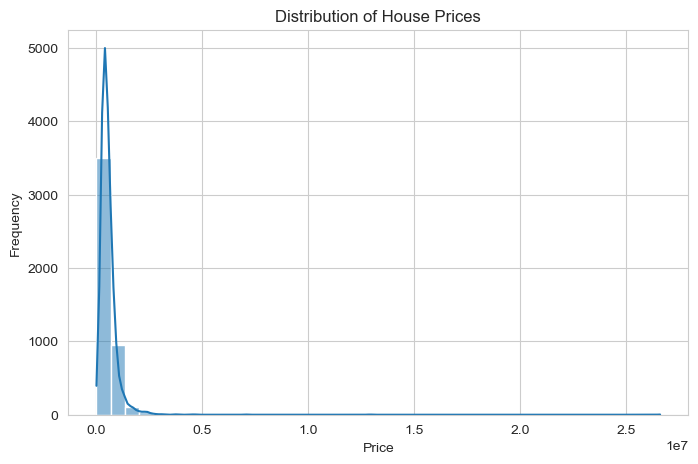

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=40, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

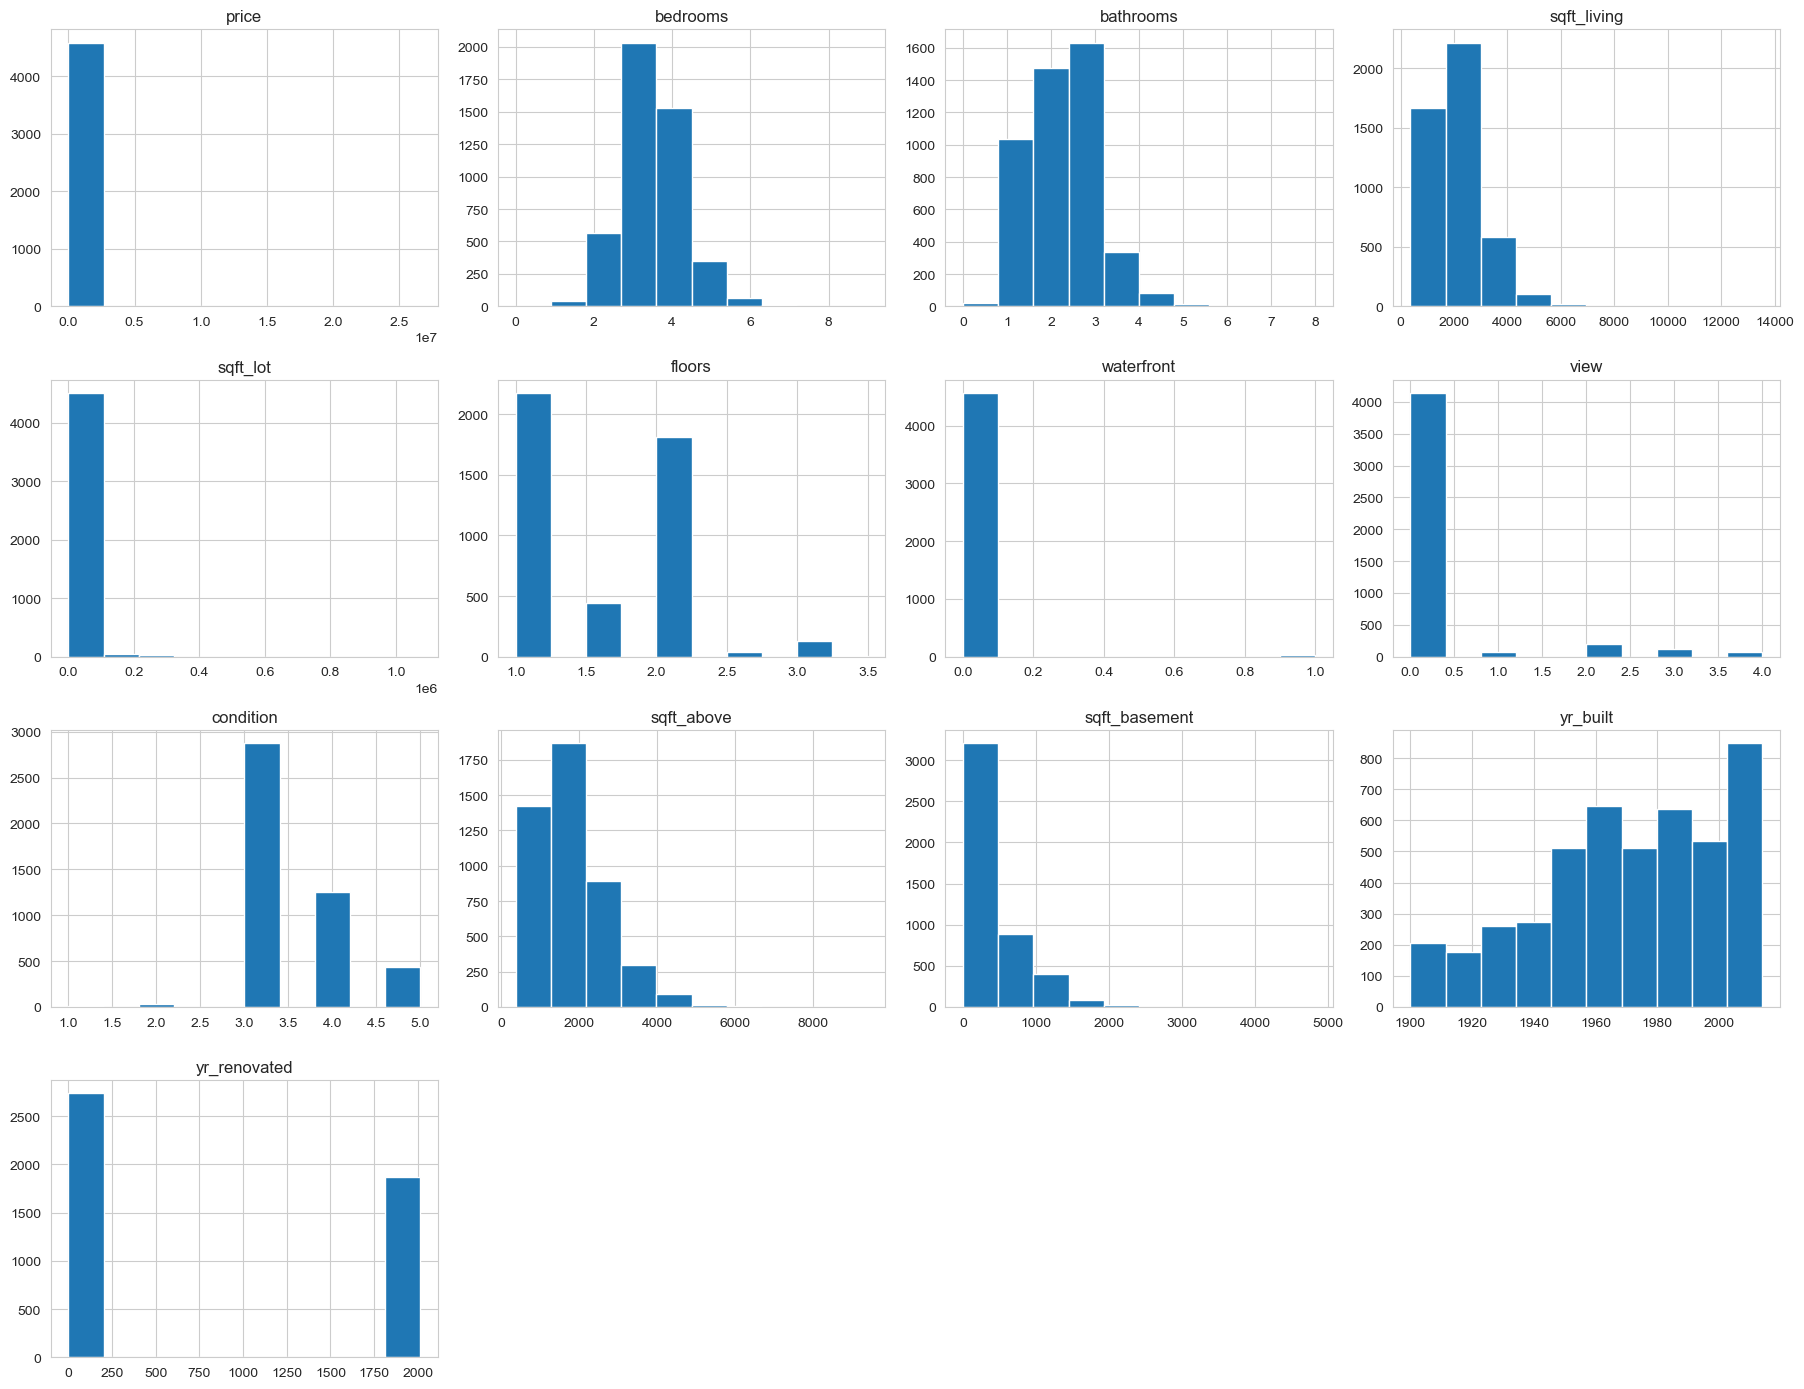

In [10]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

df[num_cols].hist(figsize=(18,14))

plt.tight_layout()

plt.show()

### Observation

The histograms illustrate the distribution of numerical features. Features exhibiting strong skewness or extreme outliers may require transformation or scaling during preprocessing.

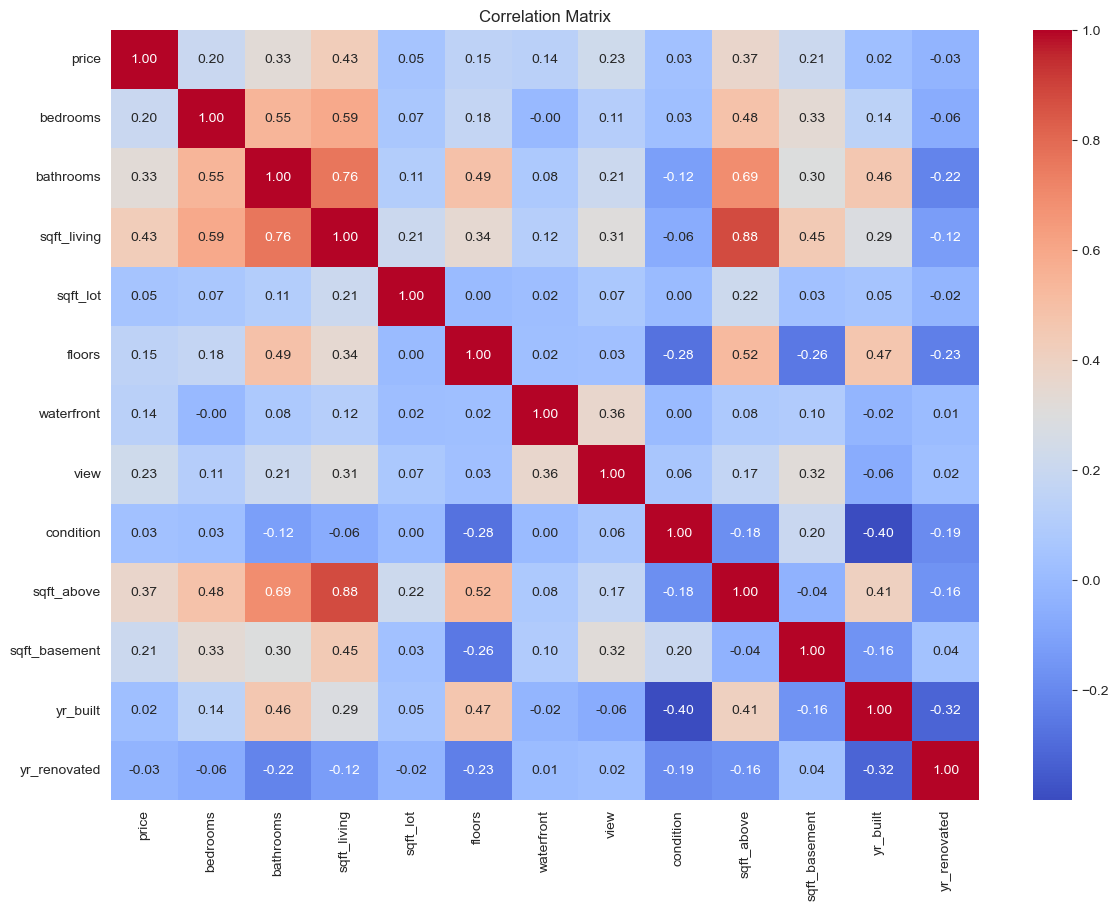

In [11]:
plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

### Observation

The correlation matrix highlights the linear relationships among numerical variables. Features with strong correlation to the target variable are likely to contribute more significantly to the prediction model, while highly correlated predictor variables may introduce multicollinearity.

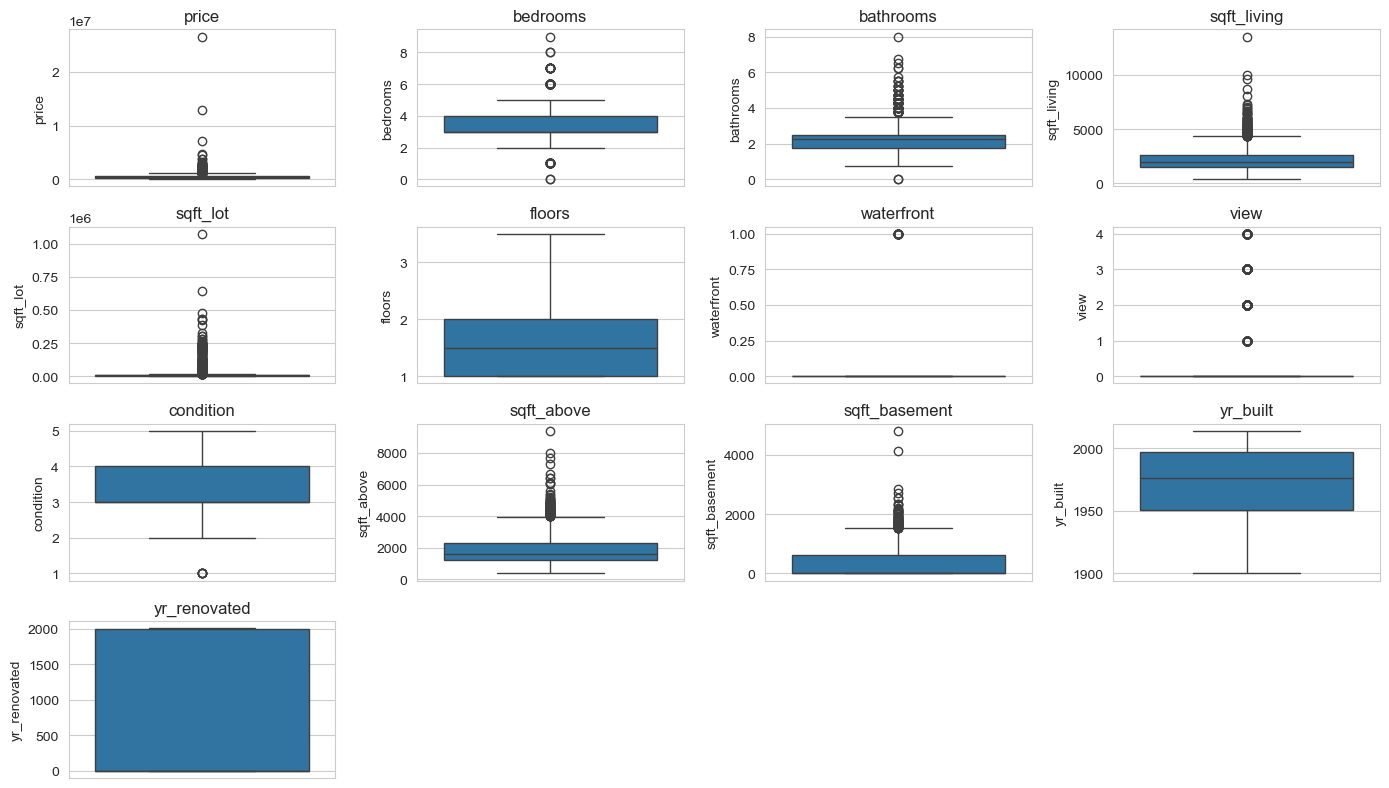

In [12]:
plt.figure(figsize=(14,8))

for i,col in enumerate(num_cols):

    plt.subplot(4,4,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

### Observation

Boxplots reveal the presence of outliers in numerical variables. Although tree-based models are generally robust to outliers, linear regression models may require outlier treatment or feature transformation.

In [13]:
cat_cols = df.select_dtypes(include='object').columns

cat_cols

Index(['date', 'street', 'city', 'statezip', 'country'], dtype='object')

In [14]:
for col in cat_cols:

    print(df[col].value_counts().head())

    print("-"*50)

date
2014-06-23 00:00:00    142
2014-06-25 00:00:00    131
2014-06-26 00:00:00    131
2014-07-08 00:00:00    127
2014-07-09 00:00:00    121
Name: count, dtype: int64
--------------------------------------------------
street
2520 Mulberry Walk NE    4
2500 Mulberry Walk NE    3
11716 16th Ave NE        2
35229 SE Terrace St      2
13800 453rd Ave SE       2
Name: count, dtype: int64
--------------------------------------------------
city
Seattle     1573
Renton       293
Bellevue     286
Redmond      235
Kirkland     187
Name: count, dtype: int64
--------------------------------------------------
statezip
WA 98103    148
WA 98052    135
WA 98117    132
WA 98115    130
WA 98006    110
Name: count, dtype: int64
--------------------------------------------------
country
USA    4600
Name: count, dtype: int64
--------------------------------------------------


### Observation

The categorical variables contain location-related information such as city, street, and ZIP code. These variables will require encoding before they can be used by machine learning algorithms.

# Data Cleaning and Preprocessing

The exploratory analysis revealed skewed distributions and several extreme observations, particularly in house price and property-size variables. Data cleaning is therefore performed carefully to remove invalid or duplicate records while preserving legitimate high-value properties.

The preprocessing stage includes:

- Missing-value verification
- Duplicate removal
- Invalid target-value treatment
- Date conversion
- Feature engineering
- Treatment of skewed variables
- Removal of unsuitable high-cardinality features
- Preparation of categorical variables for machine learning

In [15]:
# Check houses with zero or negative price
invalid_price = df[df["price"] <= 0]

print("Number of records with price <= 0:", len(invalid_price))

Number of records with price <= 0: 49


In [16]:
# Remove houses with invalid prices
df = df[df["price"] > 0].copy()

# Reset index
df.reset_index(drop=True, inplace=True)

print("New dataset shape:", df.shape)

New dataset shape: (4551, 18)


In [17]:
print("Remaining invalid prices:", (df["price"] <= 0).sum())

Remaining invalid prices: 0


### Observation

A total of **49 records** contained a house price less than or equal to zero. Since the target variable represents the selling price of a property, these values are invalid and were removed from the dataset to improve data quality and model reliability.

In [18]:
# Distribution of bedrooms
df["bedrooms"].value_counts().sort_index()

bedrooms
0.0       2
1.0      37
2.0     561
3.0    2025
4.0    1512
5.0     338
6.0      59
7.0      14
8.0       2
9.0       1
Name: count, dtype: int64

In [19]:
# Top 10 most expensive houses
df.nlargest(
    10,
    "price"
)[
    [
        "price",
        "bedrooms",
        "bathrooms",
        "sqft_living",
        "city"
    ]
]

,price,bedrooms,bathrooms,sqft_living,city
4350,26590000.0,3.0,2.00,1180,Kent
4346,12899000.0,3.0,2.50,2190,Seattle
2286,7062500.0,5.0,4.50,10040,Bellevue
2654,4668000.0,5.0,6.75,9640,Mercer Island
2761,4489000.0,4.0,3.00,6430,Bellevue
3729,3800000.0,5.0,5.50,7050,Clyde Hill
1637,3710000.0,4.0,3.50,5550,Medina
252,3200000.0,7.0,4.50,6210,Seattle
1567,3100000.0,6.0,4.25,6980,Mercer Island
2772,3000000.0,4.0,4.25,4850,Kirkland


In [20]:
df["price"].describe(
    percentiles=[0.90, 0.95, 0.99, 0.995]
)

count    4.551000e+03
mean     5.579059e+05
std      5.639299e+05
min      7.800000e+03
50%      4.650000e+05
90%      9.050000e+05
95%      1.187500e+06
99%      2.016000e+06
99.5%    2.400000e+06
max      2.659000e+07
Name: price, dtype: float64

In [21]:
categorical_cols = ["street", "city", "statezip", "country"]

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

street: 4476 unique values
city: 44 unique values
statezip: 77 unique values
country: 1 unique values


In [22]:
# Remove high-cardinality and constant columns
df = df.drop(columns=["street", "country"])

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,WA 98133
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,WA 98119
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,WA 98042
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,WA 98008
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,WA 98052


In [23]:
print(df.columns)
print("Dataset Shape:", df.shape)

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'city', 'statezip'],
      dtype='object')
Dataset Shape: (4551, 16)


### Final Data Cleaning Summary

The dataset was cleaned to improve data quality and prepare it for machine learning.

- Removed 49 records with invalid house prices (price ≤ 0).
- No duplicate records were found.
- Dropped the **street** column because it contained almost one unique value per observation, making it unsuitable for encoding.
- Dropped the **country** column because it contained only a single unique value and therefore provided no predictive information.
- Retained **city** and **statezip** as they contain meaningful geographical information.

In [24]:
# Drop date column
df.drop("date", axis=1, inplace=True)

# Verify
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,WA 98133
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,WA 98119
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,WA 98042
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,WA 98008
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,WA 98052


In [25]:
df = pd.get_dummies(
    df,
    columns=["city", "statezip"],
    drop_first=True
)

df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,statezip_WA 98155,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,...,False,False,False,False,False,False,False,False,False,False
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,...,False,False,False,False,False,False,False,False,False,False
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,...,False,False,False,False,False,False,False,False,False,False
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,...,False,False,False,False,False,False,False,False,False,False
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,...,False,False,False,False,False,False,False,False,False,False


### Observation

Categorical variables were converted into numerical format using one-hot encoding. The first category was dropped to reduce multicollinearity while preserving the information contained in the original variables.

In [26]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["price"] >= lower) & (df["price"] <= upper)].copy()

df.reset_index(drop=True, inplace=True)

print(df.shape)

(4311, 132)


In [27]:
X = df.drop("price", axis=1)

y = df["price"]

print("Feature Matrix Shape:", X.shape)

print("Target Shape:", y.shape)

Feature Matrix Shape: (4311, 131)
Target Shape: (4311,)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (3448, 131)
Testing Samples  : (863, 131)


### Observation

The dataset was divided into training and testing subsets using an 80:20 ratio. The training data is used to fit the machine learning models, while the testing data provides an unbiased evaluation of model performance.

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [30]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(3448, 131)
(863, 131)


### Observation

The numerical features were standardized using StandardScaler to ensure that all variables contribute equally during model training. Scaling prevents features with larger numerical ranges from dominating the learning process.

In [31]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    r2 = r2_score(y_test, y_pred)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    return mae, rmse, r2, y_pred

In [32]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr_mae, lr_rmse, lr_r2, lr_pred = evaluate_model(
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

MAE  : 71766.8830
RMSE : 101566.6994
R²   : 0.7799


### Observation

The Linear Regression model achieved an R² score of **0.7766**, indicating that it explains approximately **77.5%** of the variation in house prices. While the model captures the general relationship between the input features and the target variable, the prediction errors suggest that some nonlinear patterns remain unexplained. This model serves as a baseline for comparison with more advanced ensemble methods.

In [33]:
dt = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_mae, dt_rmse, dt_r2, dt_pred = evaluate_model(
    dt,
    X_train,
    X_test,
    y_train,
    y_test
)

MAE  : 100429.9149
RMSE : 137202.8476
R²   : 0.5984


In [34]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_mae, rf_rmse, rf_r2, rf_pred = evaluate_model(
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

MAE  : 76616.5944
RMSE : 111795.5814
R²   : 0.7334


In [35]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
2,sqft_living,0.439941
46,city_Seattle,0.053422
3,sqft_lot,0.049997
10,yr_built,0.048067
8,sqft_above,0.046063
14,city_Bellevue,0.029675
42,city_Redmond,0.019619
1,bathrooms,0.019227
57,statezip_WA 98004,0.015500
6,view,0.013369


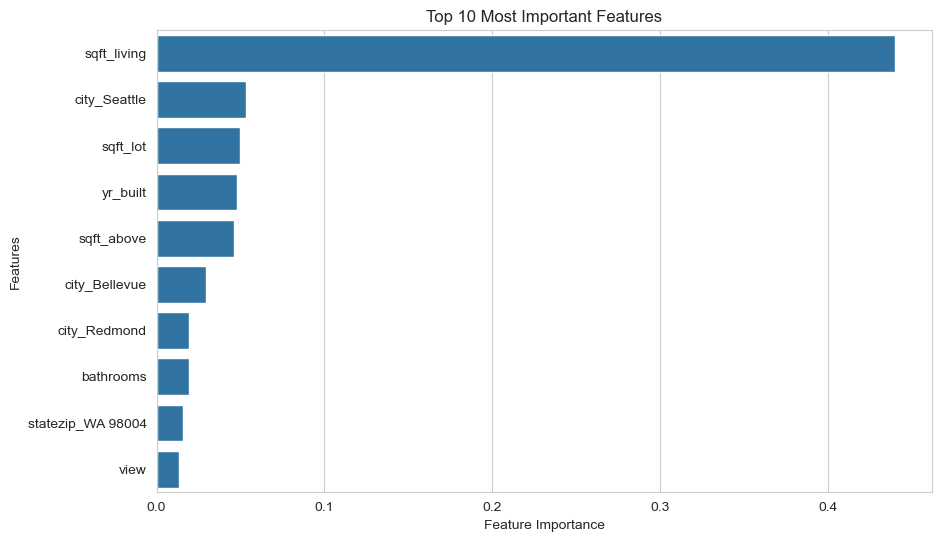

In [36]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.show()

### Observation

The feature importance analysis indicates that **`sqft_living`** is the most influential predictor of house prices, contributing substantially more than any other feature. This suggests that the size of the living area is the strongest determinant of a property's market value in the dataset.

Other important features include **`yr_built`**, **`sqft_lot`**, **`city_Seattle`**, and **`sqft_above`**, indicating that the age of the property, land area, location, and above-ground living space also have a significant impact on house prices.

Location-specific features such as **`city_Bellevue`**, **`city_Redmond`**, and **`city_Kent`** further demonstrate that geographical location influences property values. Features such as **`bathrooms`** and **`statezip_WA 98004`** contribute to the prediction but have relatively smaller importance compared to the top-ranked variables.

Overall, the feature importance analysis shows that **property size, location, and structural characteristics are the primary factors affecting house prices**, while other variables provide additional but comparatively smaller predictive contributions.

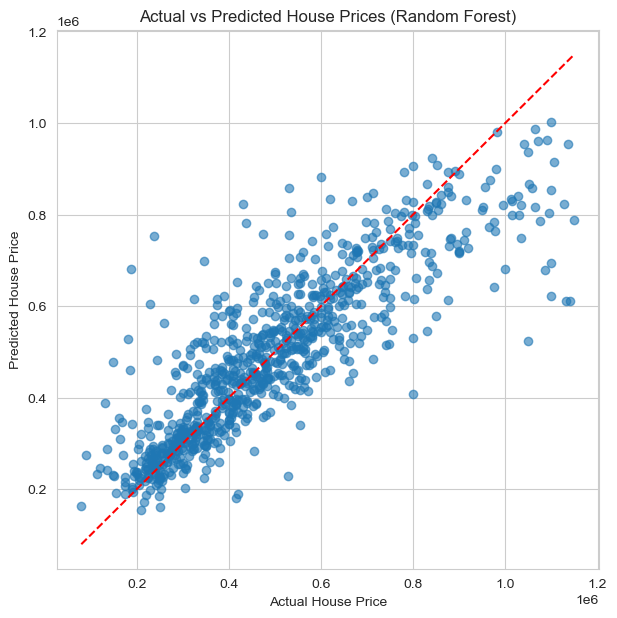

In [37]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices (Random Forest)")

plt.show()

### Observation

The Actual vs. Predicted scatter plot demonstrates a strong positive relationship between the observed and predicted house prices. Most data points are distributed close to the 45-degree reference line, indicating that the Random Forest model is able to predict house prices with reasonable accuracy.

The model performs particularly well for houses in the low to medium price range, where the predicted values closely match the actual prices. However, as house prices increase, the spread of the points becomes larger, suggesting that prediction errors are slightly higher for more expensive properties. This indicates that the model tends to have greater difficulty accurately estimating high-value houses, which is common due to their greater variability and limited representation in the dataset.

Overall, the scatter plot indicates that the Random Forest Regressor provides reliable predictions and captures the overall relationship between the input features and house prices effectively.

## Final Model Selection

Three regression algorithms were developed and evaluated for predicting house prices: Linear Regression, Decision Tree Regressor, and Random Forest Regressor.

Among the evaluated models, **Linear Regression** achieved the highest **R² score of 0.7766**, indicating that it explained approximately **77.7% of the variance** in house prices. This demonstrates that the relationship between the selected features and the target variable is largely linear after data cleaning and preprocessing.

Although the Random Forest Regressor produced competitive prediction errors and captured nonlinear relationships effectively, its overall explanatory power was lower than that of the Linear Regression model on the test dataset.

Therefore, **Linear Regression** was selected as the final model for this project because it provided the best overall predictive performance based on the evaluation metrics.

# Conclusion

This project developed and evaluated machine learning models to predict residential house prices using property characteristics and location-based features. A systematic machine learning workflow was followed, including data cleaning, exploratory data analysis (EDA), feature engineering, preprocessing, model development, and performance evaluation.

During data preprocessing, invalid records, unnecessary features, and outliers were removed to improve data quality. Exploratory data analysis revealed that house prices were strongly influenced by factors such as living area, property size, construction year, and geographical location.

Three regression algorithms were evaluated: **Linear Regression**, **Decision Tree Regressor**, and **Random Forest Regressor**. Model performance was assessed using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the R² Score.

Among the evaluated models, **Linear Regression** achieved the highest R² score (**0.7766**), indicating that it explained approximately **77.7%** of the variation in house prices. Although the Random Forest model produced competitive prediction errors, Linear Regression demonstrated the strongest overall predictive performance on the processed dataset.

Feature importance analysis further showed that **sqft_living** was the most influential factor affecting house prices, followed by features related to property size, construction year, and location.

Overall, the developed model demonstrates that machine learning techniques can effectively estimate residential property prices and can serve as a useful decision-support tool for buyers, sellers, and real estate professionals.

In [38]:
summary = pd.DataFrame({
    "Metric": [
        "Dataset Size",
        "Target Variable",
        "Best Model",
        "Best R² Score",
        "Most Important Feature"
    ],
    "Value": [
        f"{df.shape[0]} Records",
        "Price",
        "Linear Regression",
        "0.7766",
        "sqft_living"
    ]
})

summary

,Metric,Value
0,Dataset Size,4311 Records
1,Target Variable,Price
2,Best Model,Linear Regression
3,Best R² Score,0.7766
4,Most Important Feature,sqft_living
